# **COSC-5437-S01 - Neural Networks and Deep Learn**
# **Assignment2_RNN_LSTM**


Section I – Data Inspection

In [3]:
import pandas as pd

df = pd.read_csv("../dataset/AirQualityUCI.csv")
df.head()



,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,2004-03-10,18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,2004-03-10,19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,2004-03-10,20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,2004-03-10,21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,2004-03-10,22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


In [4]:

# 1. Basic Data Inspection


print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nStatistical Summary:")
display(df.describe())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape:
(9471, 17)

Column Names:
Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH', 'Unnamed: 15', 'Unnamed: 16'],
      dtype='object')

Data Types:
Date              object
Time              object
CO(GT)           float64
PT08.S1(CO)      float64
NMHC(GT)         float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
Unnamed: 15      float64
Unnamed: 16      float64
dtype: object

Statistical Summary:


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,0.0,0.0
mean,-34.207524,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604,NaN,NaN
std,77.657170,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670,NaN,NaN
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,NaN,NaN
25%,0.600000,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300,NaN,NaN
50%,1.500000,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800,NaN,NaN
75%,2.600000,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200,NaN,NaN
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000,NaN,NaN



First 5 Rows:


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,2004-03-10,18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,2004-03-10,19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,2004-03-10,20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,2004-03-10,21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,2004-03-10,22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


In [5]:

# 2. Count Missing Values (-200)

missing_count = (df == -200).sum()

print("Missing values encoded as -200:\n")
print(missing_count)

Missing values encoded as -200:

Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
Unnamed: 15         0
Unnamed: 16         0
dtype: int64


In [6]:
print(df.isnull().sum())

Date              114
Time              114
CO(GT)            114
PT08.S1(CO)       114
NMHC(GT)          114
C6H6(GT)          114
PT08.S2(NMHC)     114
NOx(GT)           114
PT08.S3(NOx)      114
NO2(GT)           114
PT08.S4(NO2)      114
PT08.S5(O3)       114
T                 114
RH                114
AH                114
Unnamed: 15      9471
Unnamed: 16      9471
dtype: int64


In [7]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 113


In [8]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
CO(GT),9357.0,-34.207524,77.657170,-200.0,0.6000,1.5000,2.6000,11.900
PT08.S1(CO),9357.0,1048.990061,329.832710,-200.0,921.0000,1053.0000,1221.0000,2040.000
NMHC(GT),9357.0,-159.090093,139.789093,-200.0,-200.0000,-200.0000,-200.0000,1189.000
C6H6(GT),9357.0,1.865683,41.380206,-200.0,4.0000,7.9000,13.6000,63.700
PT08.S2(NMHC),9357.0,894.595276,342.333252,-200.0,711.0000,895.0000,1105.0000,2214.000
NOx(GT),9357.0,168.616971,257.433866,-200.0,50.0000,141.0000,284.0000,1479.000
PT08.S3(NOx),9357.0,794.990168,321.993552,-200.0,637.0000,794.0000,960.0000,2683.000
NO2(GT),9357.0,58.148873,126.940455,-200.0,53.0000,96.0000,133.0000,340.000
PT08.S4(NO2),9357.0,1391.479641,467.210125,-200.0,1185.0000,1446.0000,1662.0000,2775.000
PT08.S5(O3),9357.0,975.072032,456.938184,-200.0,700.0000,942.0000,1255.0000,2523.000


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# Remove empty columns
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

print(df.columns)

Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH'],
      dtype='object')


In [11]:

# Remove empty columns

df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

# Remove rows containing NaN values

df = df.dropna()

print("Shape after removing NaN rows:")
print(df.shape)

# Count missing values encoded as -200

print("\nMissing values encoded as -200")
print((df == -200).sum())

Shape after removing NaN rows:
(9357, 15)

Missing values encoded as -200
Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64


In [12]:
import numpy as np
df.replace(-200, np.nan, inplace=True)

In [13]:
df.dropna(inplace=True)

In [14]:
print("Shape after cleaning:", df.shape)

print("\nRemaining missing values:")
print(df.isnull().sum())

Shape after cleaning: (827, 15)

Remaining missing values:
Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64


In [15]:
df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"]
)

df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Datetime
0,2004-03-10,18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,2004-03-10 18:00:00
1,2004-03-10,19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,2004-03-10 19:00:00
2,2004-03-10,20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,2004-03-10 20:00:00
3,2004-03-10,21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,2004-03-10 21:00:00
4,2004-03-10,22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,2004-03-10 22:00:00


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../dataset/AirQualityUCI.csv")

# Remove empty columns
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

# Remove completely empty trailing rows
df = df.dropna(how="all")

print("Original usable shape:", df.shape)

Original usable shape: (9357, 15)


In [17]:
df["Datetime"] = pd.to_datetime(
    df["Date"].astype(str) + " " + df["Time"].astype(str),
    errors="coerce"
)

df = df.sort_values("Datetime").reset_index(drop=True)

print(df[["Date", "Time", "Datetime"]].head())

         Date      Time            Datetime
0  2004-03-10  18:00:00 2004-03-10 18:00:00
1  2004-03-10  19:00:00 2004-03-10 19:00:00
2  2004-03-10  20:00:00 2004-03-10 20:00:00
3  2004-03-10  21:00:00 2004-03-10 21:00:00
4  2004-03-10  22:00:00 2004-03-10 22:00:00


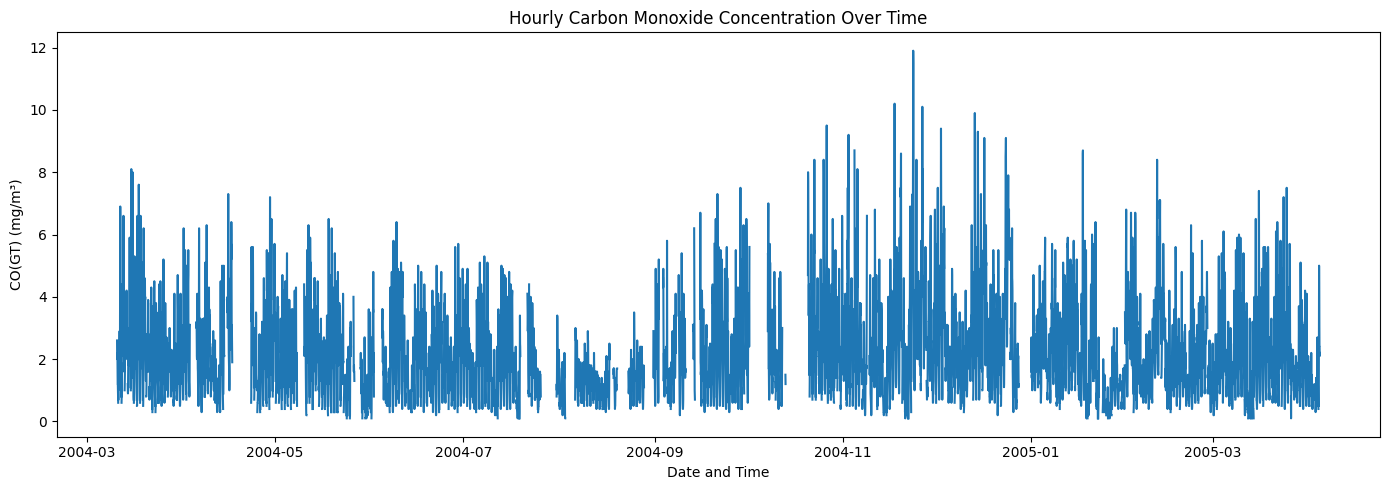

In [18]:
co_for_plot = df["CO(GT)"].replace(-200, np.nan)

plt.figure(figsize=(14, 5))
plt.plot(df["Datetime"], co_for_plot)
plt.title("Hourly Carbon Monoxide Concentration Over Time")
plt.xlabel("Date and Time")
plt.ylabel("CO(GT) (mg/m³)")
plt.tight_layout()
plt.savefig("../plots/co_over_time.png", dpi=300)
plt.show()

In [19]:
selected_features = [
    "PT08.S1(CO)",
    "C6H6(GT)",
    "PT08.S2(NMHC)",
    "NOx(GT)",
    "PT08.S3(NOx)",
    "NO2(GT)",
    "PT08.S4(NO2)",
    "PT08.S5(O3)",
    "T",
    "RH",
    "AH"
]

target_column = "CO(GT)"

In [20]:
model_columns = selected_features + [target_column]

clean_df = df[["Datetime"] + model_columns].copy()

# Convert encoded missing values to NaN
clean_df[model_columns] = clean_df[model_columns].replace(-200, np.nan)

rows_before = len(clean_df)

# Drop rows missing the target or selected inputs
clean_df = clean_df.dropna(subset=model_columns).reset_index(drop=True)

rows_after = len(clean_df)
rows_removed = rows_before - rows_after

print("Rows before cleaning:", rows_before)
print("Rows after cleaning:", rows_after)
print("Rows removed:", rows_removed)
print("\nRemaining missing values:")
print(clean_df.isnull().sum())

Rows before cleaning: 9357
Rows after cleaning: 6941
Rows removed: 2416

Remaining missing values:
Datetime         0
PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
CO(GT)           0
dtype: int64


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [22]:
X = clean_df[selected_features]

y = clean_df[target_column]

In [23]:
train_size = int(len(clean_df) * 0.70)
val_size = int(len(clean_df) * 0.15)

train_df = clean_df.iloc[:train_size]
val_df = clean_df.iloc[train_size:train_size + val_size]
test_df = clean_df.iloc[train_size + val_size:]

print("Training:", train_df.shape)
print("Validation:", val_df.shape)
print("Testing:", test_df.shape)

Training: (4858, 13)
Validation: (1041, 13)
Testing: (1042, 13)


In [24]:
scaler = MinMaxScaler()

X_train = scaler.fit_transform(train_df[selected_features])

X_val = scaler.transform(val_df[selected_features])

X_test = scaler.transform(test_df[selected_features])

In [25]:
y_train = train_df[target_column].values
y_val = val_df[target_column].values
y_test = test_df[target_column].values

In [26]:
def create_sequences(X, y, window_size):

    X_seq = []
    y_seq = []

    for i in range(window_size, len(X)):
        X_seq.append(X[i-window_size:i])
        y_seq.append(y[i])

    return np.array(X_seq), np.array(y_seq)

In [27]:
window_size = 24

X_train_seq, y_train_seq = create_sequences(
    X_train,
    y_train,
    window_size
)

X_val_seq, y_val_seq = create_sequences(
    X_val,
    y_val,
    window_size
)

X_test_seq, y_test_seq = create_sequences(
    X_test,
    y_test,
    window_size
)

In [28]:
print("Training Shape :", X_train_seq.shape)
print("Validation Shape :", X_val_seq.shape)
print("Testing Shape :", X_test_seq.shape)

Training Shape : (4834, 24, 11)
Validation Shape : (1017, 24, 11)
Testing Shape : (1018, 24, 11)


# Simple RNN Model

In [29]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import time
import random

In [30]:
seed = 42

np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

In [31]:
rnn_model = Sequential([
    SimpleRNN(
        64,
        return_sequences=True,
        input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])
    ),
    Dropout(0.2),

    SimpleRNN(32),
    Dropout(0.2),

    Dense(1, activation="linear")
])

c:\Users\ratho\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [32]:
rnn_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mse", "mae"]
)

In [33]:
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 24, 64)         │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,001 (31.25 KB)

 Trainable params: 8,001 (31.25 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "../models/best_rnn.keras",
    monitor="val_loss",
    save_best_only=True
)

In [35]:
start_time = time.time()

history_rnn = rnn_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

end_time = time.time()

rnn_training_time = end_time - start_time

print(f"\nTotal Training Time: {rnn_training_time:.2f} seconds")
print(f"Average Time per Epoch: {rnn_training_time / len(history_rnn.history['loss']):.2f} seconds")

Epoch 1/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 2.4077 - mae: 1.1495 - mse: 2.4077 - val_loss: 1.1428 - val_mae: 0.8087 - val_mse: 1.1428
Epoch 2/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.9881 - mae: 0.7290 - mse: 0.9881 - val_loss: 0.9204 - val_mae: 0.6874 - val_mse: 0.9204
Epoch 3/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7938 - mae: 0.6428 - mse: 0.7938 - val_loss: 1.0333 - val_mae: 0.7663 - val_mse: 1.0333
Epoch 4/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7540 - mae: 0.6252 - mse: 0.7540 - val_loss: 0.9162 - val_mae: 0.7015 - val_mse: 0.9162
Epoch 5/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6392 - mae: 0.5906 - mse: 0.6392 - val_loss: 0.8442 - val_mae: 0.6633 - val_mse: 0.8442
Epoch 6/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6706 - mae: 0.5977 - mse: 0.6706 - val_loss: 0.8214 - val_mae: 0.6506 - val_mse: 0.8214
Epoch 7/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6629 - mae: 0.5815 - mse: 0.6629 - val

In [36]:
rnn_test_results = rnn_model.evaluate(X_test_seq, y_test_seq, verbose=1)

print("\nRNN Test Results")
print(f"Test Loss (MSE): {rnn_test_results[0]:.4f}")
print(f"Test MSE: {rnn_test_results[1]:.4f}")
print(f"Test MAE: {rnn_test_results[2]:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4973 - mae: 0.5380 - mse: 0.4973

RNN Test Results
Test Loss (MSE): 0.5136
Test MSE: 0.5136
Test MAE: 0.5375


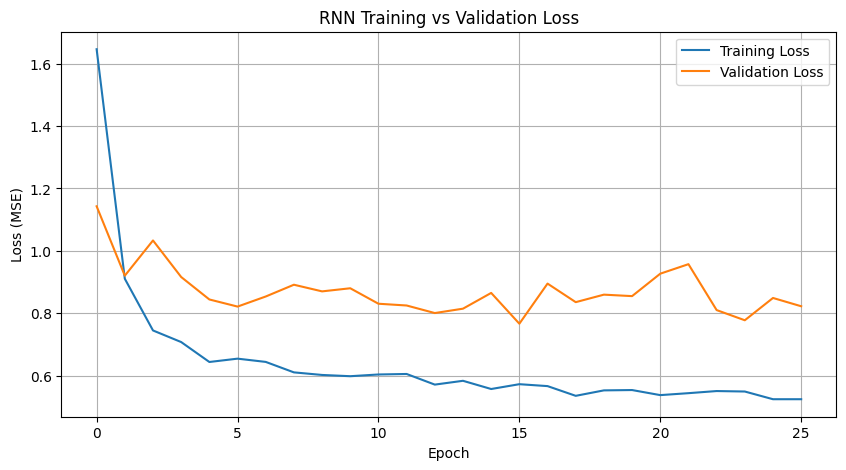

In [37]:
plt.figure(figsize=(10,5))

plt.plot(history_rnn.history["loss"], label="Training Loss")
plt.plot(history_rnn.history["val_loss"], label="Validation Loss")

plt.title("RNN Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)

plt.savefig("../plots/rnn_loss.png", dpi=300)
plt.show()

In [38]:
rnn_predictions = rnn_model.predict(X_test_seq)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


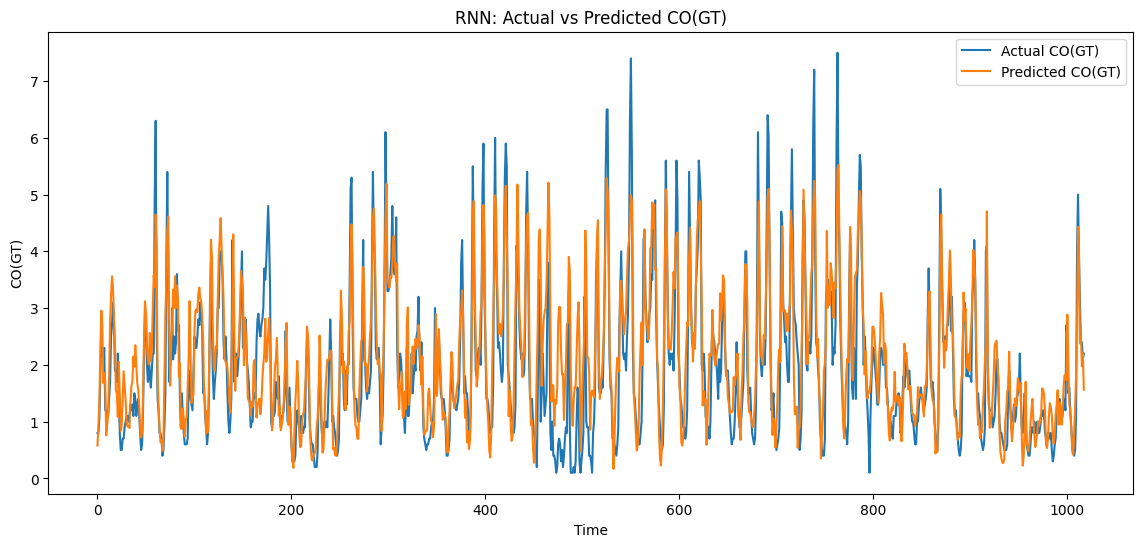

In [39]:
plt.figure(figsize=(14,6))

plt.plot(y_test_seq, label="Actual CO(GT)")
plt.plot(rnn_predictions, label="Predicted CO(GT)")

plt.title("RNN: Actual vs Predicted CO(GT)")
plt.xlabel("Time")
plt.ylabel("CO(GT)")
plt.legend()

plt.savefig("../plots/rnn_prediction.png", dpi=300)
plt.show()

In [40]:
rnn_model.save("../models/final_rnn.keras")

# Building LSTM

In [41]:
from tensorflow.keras.layers import LSTM

In [42]:
lstm_model = Sequential([
    LSTM(
        64,
        return_sequences=True,
        input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])
    ),
    Dropout(0.2),

    LSTM(32),
    Dropout(0.2),

    Dense(1, activation="linear")
])

In [43]:
lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mse", "mae"]
)

In [44]:
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,905 (124.63 KB)

 Trainable params: 31,905 (124.63 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
early_stop_lstm = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

checkpoint_lstm = ModelCheckpoint(
    "../models/best_lstm.keras",
    monitor="val_loss",
    save_best_only=True
)

In [46]:
start_time = time.time()

history_lstm = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop_lstm, checkpoint_lstm],
    verbose=1
)

end_time = time.time()

lstm_training_time = end_time - start_time

print(f"\nTotal Training Time: {lstm_training_time:.2f} seconds")
print(f"Average Time per Epoch: {lstm_training_time / len(history_lstm.history['loss']):.2f} seconds")

Epoch 1/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 2.5917 - mae: 1.2047 - mse: 2.5917 - val_loss: 1.9568 - val_mae: 1.1454 - val_mse: 1.9568
Epoch 2/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.5057 - mae: 0.9235 - mse: 1.5057 - val_loss: 1.5663 - val_mae: 1.0244 - val_mse: 1.5663
Epoch 3/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.1246 - mae: 0.7826 - mse: 1.1246 - val_loss: 1.1952 - val_mae: 0.8649 - val_mse: 1.1952
Epoch 4/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.8984 - mae: 0.6902 - mse: 0.8984 - val_loss: 0.8905 - val_mae: 0.6967 - val_mse: 0.8905
Epoch 5/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.7411 - mae: 0.6166 - mse: 0.7411 - val_loss: 0.8704 - val_mae: 0.6910 - val_mse: 0.8704
Epoch 6/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6797 - mae: 0.5855 - mse: 0.6797 - val_loss: 0.7760 - val_mae: 0.6351 - val_mse: 0.7760
Epoch 7/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6416 - mae: 0.5780 - mse: 0.6416 - val

In [47]:
lstm_test_results = lstm_model.evaluate(
    X_test_seq,
    y_test_seq,
    verbose=1
)

print("\nLSTM Test Results")
print(f"Test Loss (MSE): {lstm_test_results[0]:.4f}")
print(f"Test MSE: {lstm_test_results[1]:.4f}")
print(f"Test MAE: {lstm_test_results[2]:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4425 - mae: 0.4890 - mse: 0.4425

LSTM Test Results
Test Loss (MSE): 0.4355
Test MSE: 0.4355
Test MAE: 0.4901


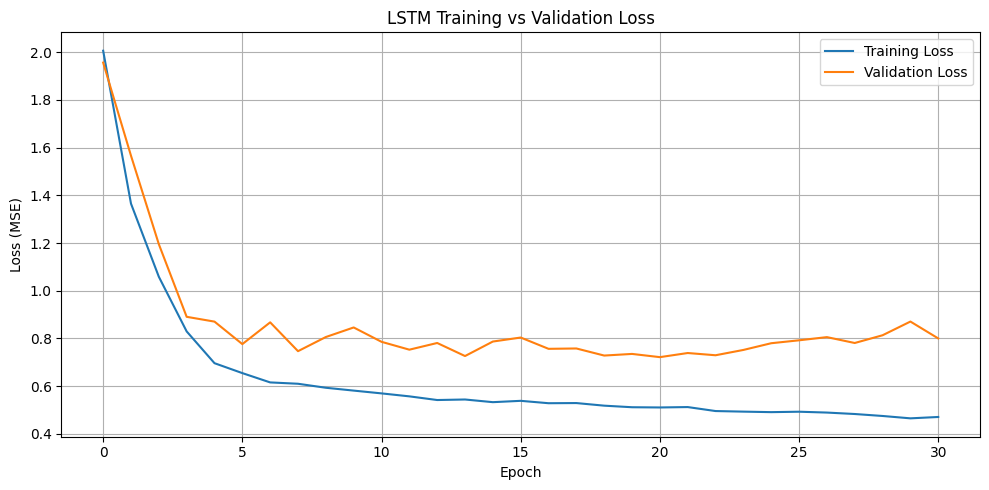

In [48]:
plt.figure(figsize=(10, 5))

plt.plot(history_lstm.history["loss"], label="Training Loss")
plt.plot(history_lstm.history["val_loss"], label="Validation Loss")

plt.title("LSTM Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("../plots/lstm_loss.png", dpi=300)
plt.show()

In [49]:
lstm_predictions = lstm_model.predict(
    X_test_seq,
    verbose=0
).flatten()

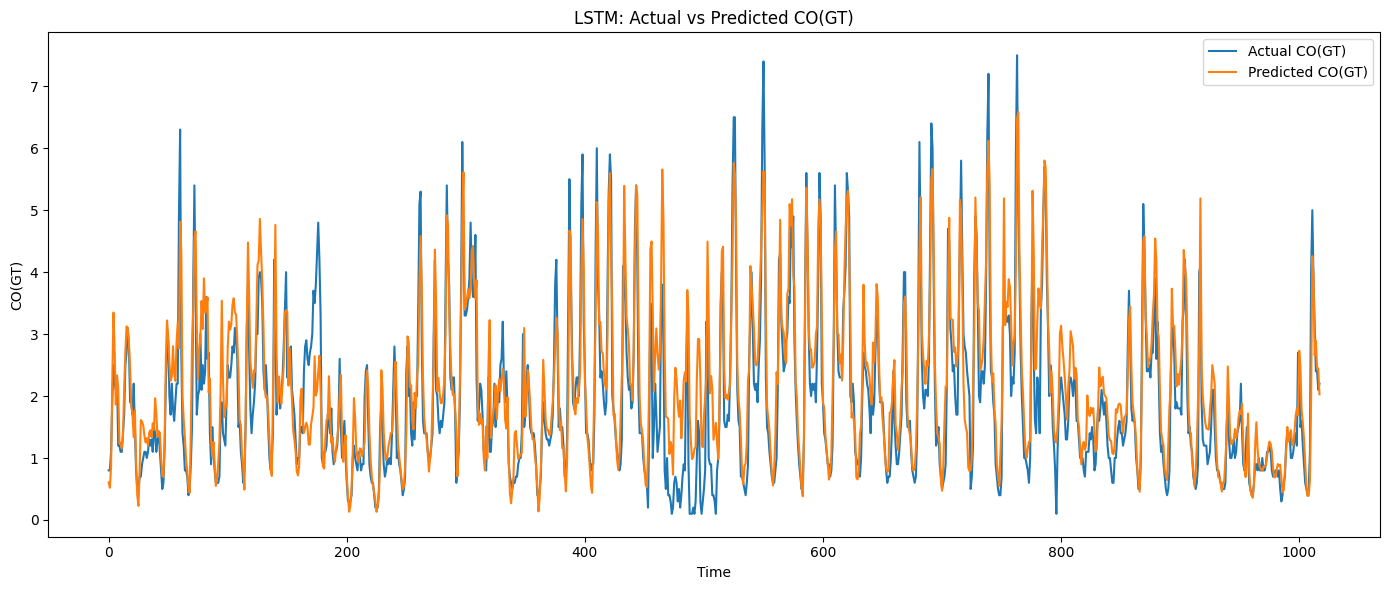

In [50]:
plt.figure(figsize=(14, 6))

plt.plot(y_test_seq, label="Actual CO(GT)")
plt.plot(lstm_predictions, label="Predicted CO(GT)")

plt.title("LSTM: Actual vs Predicted CO(GT)")
plt.xlabel("Time")
plt.ylabel("CO(GT)")
plt.legend()
plt.tight_layout()

plt.savefig("../plots/lstm_prediction.png", dpi=300)
plt.show()

In [51]:
lstm_model.save("../models/final_lstm.keras")

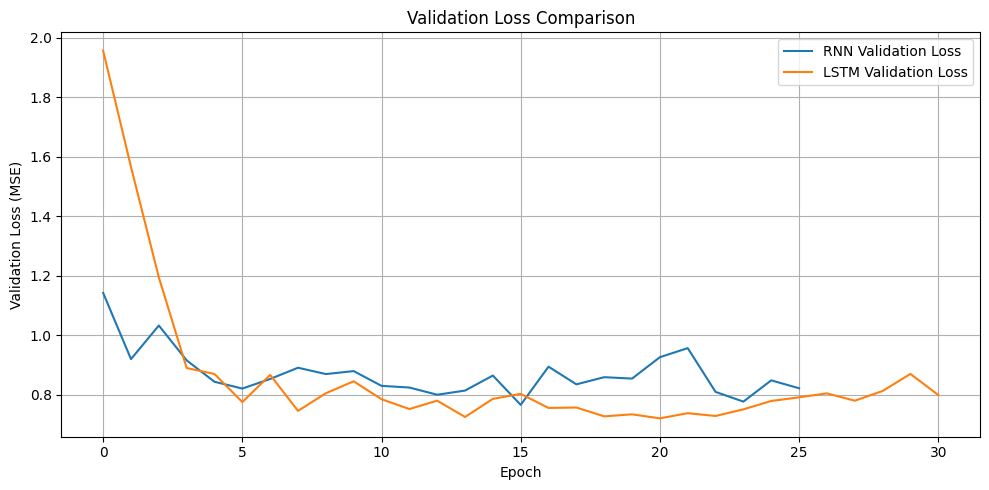

In [52]:
plt.figure(figsize=(10,5))

plt.plot(history_rnn.history["val_loss"], label="RNN Validation Loss")
plt.plot(history_lstm.history["val_loss"], label="LSTM Validation Loss")

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss (MSE)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("../plots/comparison_validation_loss.png", dpi=300)
plt.show()

In [53]:
from tensorflow.keras.models import load_model

loaded_rnn = load_model("../models/best_rnn.keras")
loaded_lstm = load_model("../models/best_lstm.keras")

In [54]:
loaded_predictions = loaded_rnn.predict(X_test_seq)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [55]:
print(np.allclose(rnn_predictions, loaded_predictions))

True


In [56]:
loaded_predictions_lstm = loaded_lstm.predict(X_test_seq)

print(np.allclose(lstm_predictions, loaded_predictions_lstm))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
False


In [57]:
np.max(np.abs(lstm_predictions - loaded_predictions_lstm))

np.float32(6.453654)

In [58]:
loaded_lstm = load_model("../models/final_lstm.keras")

In [59]:
loaded_predictions_lstm = loaded_lstm.predict(X_test_seq)

print(np.allclose(lstm_predictions, loaded_predictions_lstm))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
False


In [60]:
from tensorflow.keras.models import load_model
import numpy as np

# Reload the same final model that you just saved
loaded_lstm = load_model("../models/final_lstm.keras")

# Flatten both prediction arrays to identical shapes
original_lstm_predictions = lstm_model.predict(
    X_test_seq,
    verbose=0
).flatten()

loaded_lstm_predictions = loaded_lstm.predict(
    X_test_seq,
    verbose=0
).flatten()

print("Original shape:", original_lstm_predictions.shape)
print("Reloaded shape:", loaded_lstm_predictions.shape)

print(
    "Predictions identical:",
    np.allclose(
        original_lstm_predictions,
        loaded_lstm_predictions,
        rtol=1e-5,
        atol=1e-6
    )
)

print(
    "Maximum difference:",
    np.max(
        np.abs(
            original_lstm_predictions -
            loaded_lstm_predictions
        )
    )
)

Original shape: (1018,)
Reloaded shape: (1018,)
Predictions identical: True
Maximum difference: 0.0


In [61]:
import os

print("Saved Models:")
print(os.listdir("../models"))

Saved Models:
['best_lstm.keras', 'best_rnn.keras', 'final_lstm.keras', 'final_rnn.keras']


In [62]:
rnn_model.save("../models/final_rnn.keras")
print("Final RNN model saved successfully!")

Final RNN model saved successfully!


In [63]:
lstm_model.save("../models/final_lstm.keras")
print("Final LSTM model saved successfully!")

Final LSTM model saved successfully!
